In [1]:
import zipfile
import os

# Path to your ZIP file
zip_path = r'C:/Users/HP/Downloads/balanced_labeled_photos.zip'
extract_path = r'yelp_photos'  # where to extract

# Unzip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Check folders
print("Extracted folders:", os.listdir(extract_path))


Extracted folders: ['balanced_labeled_photos']


In [2]:
import os

image_extensions = ('.jpg', '.jpeg', '.png')
image_count = 0

for root, dirs, files in os.walk('yelp_photos/balanced_labeled_photos'):
    for file in files:
        if file.lower().endswith(image_extensions):
            image_count += 1

print(f"Total number of image files: {image_count}")


Total number of image files: 94239


In [3]:
from collections import defaultdict

category_counts = defaultdict(int)

for root, dirs, files in os.walk('yelp_photos/balanced_labeled_photos'):
    for file in files:
        if file.lower().endswith(image_extensions):
            class_name = os.path.basename(root)
            category_counts[class_name] += 1

print("Images per category:")
for category, count in category_counts.items():
    print(f"{category}: {count}")


Images per category:
drink: 15670
food: 20000
inside: 20000
menu: 20000
outside: 18569


In [4]:
import os
import shutil
import random

source_dir = 'yelp_photos/balanced_labeled_photos'
target_dir = 'yelp_photos_10k_balanced'
max_per_class = 10000
image_extensions = ('.jpg', '.jpeg', '.png')

# Create target folder
os.makedirs(target_dir, exist_ok=True)

# Process each class folder
for class_name in os.listdir(source_dir):
    class_source_path = os.path.join(source_dir, class_name)
    class_target_path = os.path.join(target_dir, class_name)
    os.makedirs(class_target_path, exist_ok=True)

    # Get all image files
    image_files = [f for f in os.listdir(class_source_path)
                   if f.lower().endswith(image_extensions)]

    # Randomly select 10,000 images
    selected_images = random.sample(image_files, min(max_per_class, len(image_files)))

    # Copy selected images to new balanced folder
    for img_file in selected_images:
        src_path = os.path.join(class_source_path, img_file)
        dst_path = os.path.join(class_target_path, img_file)
        shutil.copy2(src_path, dst_path)

    print(f"{class_name}: {len(selected_images)} images copied.")


drink: 10000 images copied.
food: 10000 images copied.
inside: 10000 images copied.
menu: 10000 images copied.
outside: 10000 images copied.


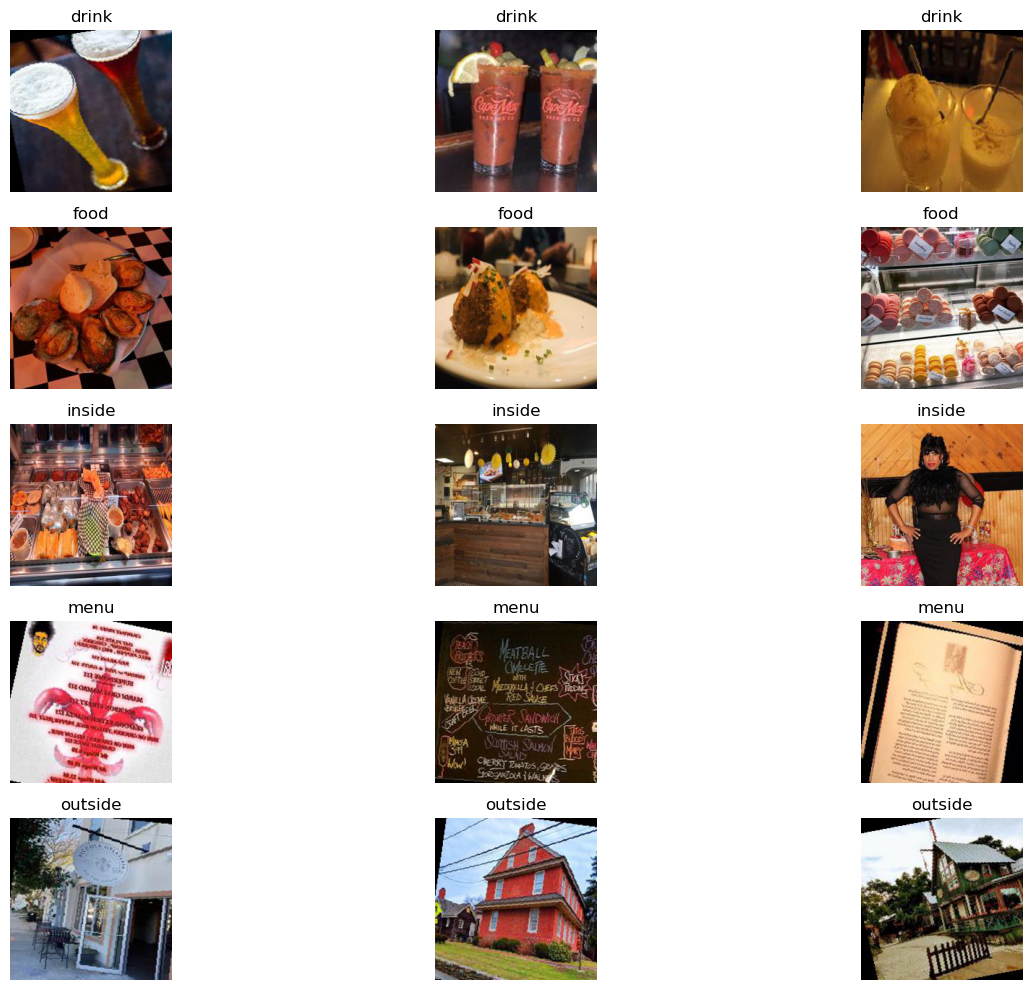

In [5]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

base_dir = 'yelp_photos_10k_balanced'
classes = os.listdir(base_dir)
img_per_class = 3  # adjust as needed

plt.figure(figsize=(15, 10))

for idx, class_name in enumerate(classes):
    class_path = os.path.join(base_dir, class_name)
    image_files = random.sample(os.listdir(class_path), img_per_class)

    for i, img_name in enumerate(image_files):
        img_path = os.path.join(class_path, img_name)
        img = mpimg.imread(img_path)
        plt.subplot(len(classes), img_per_class, idx * img_per_class + i + 1)
        plt.imshow(img)
        plt.title(f"{class_name}")
        plt.axis('off')

plt.tight_layout()
plt.show()


In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (224, 224)
batch_size = 32

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = datagen.flow_from_directory(
    'yelp_photos_10k_balanced',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_gen = datagen.flow_from_directory(
    'yelp_photos_10k_balanced',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=True
)

num_classes = train_gen.num_classes


Found 40000 images belonging to 5 classes.
Found 10000 images belonging to 5 classes.


In [7]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Dropout, Input

# Load VGG16
vgg = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
vgg.trainable = False  # Freeze for Round 1

# Add custom layers
x = Flatten()(vgg.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=vgg.input, outputs=output)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       6,422,784 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 21,171,013 (80.76 MB)

 Trainable params: 6,456,325 (24.63 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [10]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(patience=3, restore_best_weights=True),
    ModelCheckpoint('vgg16_yelp_baseline.keras', save_best_only=True)
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5,
    callbacks=callbacks
)


Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.7023 - loss: 0.7880 

C:\Users\HP\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 18183s 15s/step - accuracy: 0.7023 - loss: 0.7879 - val_accuracy: 0.8844 - val_loss: 0.4107
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8940s 7s/step - accuracy: 0.8086 - loss: 0.5115 - val_accuracy: 0.8959 - val_loss: 0.3847
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8388s 7s/step - accuracy: 0.8364 - loss: 0.4495 - val_accuracy: 0.9057 - val_loss: 0.3547
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6930s 6s/step - accuracy: 0.8472 - loss: 0.4146 - val_accuracy: 0.9014 - val_loss: 0.3630
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6535s 5s/step - accuracy: 0.8553 - loss: 0.4008 - val_accuracy: 0.9111 - val_loss: 0.3317


In [11]:
model.save("my_vgg16_finetuned_model.h5")


In [13]:
model.save("my_model.keras")  # Recommended format


In [14]:
model.save("C:/Users/HP/Downloads/my_model.keras")


313/313 ━━━━━━━━━━━━━━━━━━━━ 1475s 5s/step
AUC Score: 0.49843300625
Confusion Matrix:
 [[420 349 409 407 415]
 [404 374 445 393 384]
 [431 352 398 397 422]
 [428 385 412 382 393]
 [425 371 411 392 401]]
Classification Report:
               precision    recall  f1-score   support

       drink       0.20      0.21      0.20      2000
        food       0.20      0.19      0.20      2000
      inside       0.19      0.20      0.20      2000
        menu       0.19      0.19      0.19      2000
     outside       0.20      0.20      0.20      2000

    accuracy                           0.20     10000
   macro avg       0.20      0.20      0.20     10000
weighted avg       0.20      0.20      0.20     10000



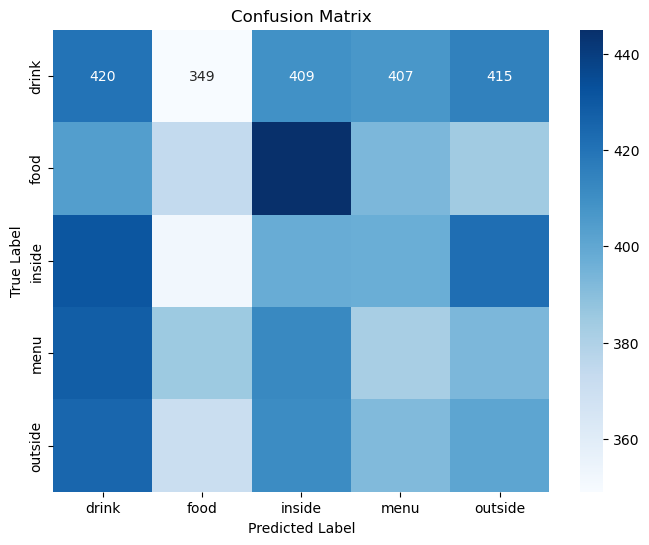

In [16]:
import numpy as np
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Predict probabilities
y_probs = model.predict(val_gen, verbose=1)  # shape: (num_samples, num_classes)

# Step 2: Predicted class labels
y_pred = np.argmax(y_probs, axis=1)

# Step 3: True labels from val_gen (assuming categorical labels)
y_true = val_gen.classes                         # shape: (num_samples,)
class_indices = list(val_gen.class_indices.keys())

# Step 4: If needed, convert true labels to one-hot encoding
from tensorflow.keras.utils import to_categorical
y_true_cat = to_categorical(y_true, num_classes=len(class_indices))

# Step 5: AUC (macro average, one-vs-rest)
auc = roc_auc_score(y_true_cat, y_probs, multi_class='ovr', average='macro')
print("AUC Score:", auc)

# Step 6: Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

# Step 7: Classification Report
print("Classification Report:\n", classification_report(y_true, y_pred, target_names=class_indices))

# Step 8: Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_indices, yticklabels=class_indices)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


In [ ]:
({'input_1': image_tensor, 'meta_input': metadata_array}, label)


In [ ]:
vgg_base.trainable = False


In [ ]:
({'input_1': image_batch, 'meta_input': metadata_batch}, labels)


In [49]:
import numpy as np

def combined_generator(image_gen, metadata_array, batch_size):
    """
    image_gen: ImageDataGenerator flow_from_directory generator
    metadata_array: np.array with metadata aligned with images in image_gen
    """
    while True:
        image_batch, label_batch = next(image_gen)
        batch_indices = image_gen.index_array[image_gen.batch_index * batch_size : (image_gen.batch_index + 1) * batch_size]
        # Get metadata batch using indices (may need to handle last batch carefully)
        meta_batch = metadata_array[batch_indices]
        yield [image_batch, meta_batch], label_batch


In [50]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Flatten, Input, Concatenate, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Image input
img_input = Input(shape=(224, 224, 3), name='image_input')

# Metadata input: suppose metadata has 10 features
metadata_input = Input(shape=(10,), name='metadata_input')

# Load VGG16 base, exclude top fully connected layers
vgg_base = VGG16(include_top=False, weights='imagenet', input_tensor=img_input)

# Freeze base initially
for layer in vgg_base.layers:
    layer.trainable = False

# Flatten VGG output
x = Flatten()(vgg_base.output)

# Combine with metadata input
combined = Concatenate()([x, metadata_input])

# Add dense layers on top
x = Dense(256, activation='relu')(combined)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

# Output layer (adjust units and activation based on num classes)
num_classes = 5  # for example
output = Dense(num_classes, activation='softmax')(x)

# Define full model
model = Model(inputs=[img_input, metadata_input], outputs=output)

# Compile model with categorical_crossentropy loss
model.compile(optimizer=Adam(learning_rate=1e-3), loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv1 (Conv2D)         │ (None, 224, 224, 64)      │           1,792 │ image_input[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv2 (Conv2D)         │ (None, 224, 224, 64)      │          36,928 │ block1_conv1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_pool (MaxPooling2D)    │ (None, 112, 112, 64)      │               0 │ block1_conv2[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_conv1 (Conv2D)         │ (None, 112, 112, 128)     │          73,856 │ block1_pool[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_conv2 (Conv2D)         │ (None, 112, 112, 128)     │         147,584 │ block2_conv1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_pool (MaxPooling2D)    │ (None, 56, 56, 128)       │               0 │ block2_conv2[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block3_conv1 (Conv2D)         │ (None, 56, 56, 256)       │         295,168 │ block2_pool[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block3_conv2 (Conv2D)         │ (None, 56, 56, 256)       │         590,080 │ block3_conv1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block3_conv3 (Conv2D)         │ (None, 56, 56, 256)       │         590,080 │ block3_conv2[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block3_pool (MaxPooling2D)    │ (None, 28, 28, 256)       │               0 │ block3_conv3[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block4_conv1 (Conv2D)         │ (None, 28, 28, 512)       │       1,180,160 │ block3_pool[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block4_conv2 (Conv2D)         │ (None, 28, 28, 512)       │       2,359,808 │ block4_conv1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block4_conv3 (Conv2D)         │ (None, 28, 28, 512)       │       2,359,808 │ block4_conv2[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block4_pool (MaxPooling2D)    │ (None, 14, 14, 512)       │               0 │ block4_conv3[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block5_conv1 (Conv2D)         │ (None, 14, 14, 512)       │       2,359,808 │ block4_pool[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block5_conv2 (Conv2D)         │ (None, 14, 14, 512)       │       2,359,808 │ block5_conv1[0][0]         │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 21,173,573 (80.77 MB)

 Trainable params: 6,458,885 (24.64 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [52]:
import json

metadata_list = []
with open('C:/Users/HP/Downloads/photos.json', 'r') as f:
    for line in f:
        try:
            metadata_list.append(json.loads(line))
        except json.JSONDecodeError as e:
            print("Error decoding line:", e)

# View the first 2 items
print(metadata_list[:2])

[{'photo_id': 'zsvj7vloL4L5jhYyPIuVwg', 'business_id': 'Nk-SJhPlDBkAZvfsADtccA', 'caption': 'Nice rock artwork everywhere and craploads of taps.', 'label': 'inside'}, {'photo_id': 'HCUdRJHHm_e0OCTlZetGLg', 'business_id': 'yVZtL5MmrpiivyCIrVkGgA', 'caption': '', 'label': 'outside'}]


In [53]:
import pandas as pd

# Convert list of dicts to DataFrame
metadata_df = pd.DataFrame(metadata_list)

# Add filename column: the filename for each image in your folder is "<photo_id>.jpg"
metadata_df['filename'] = metadata_df['photo_id'] + '.jpg'

# Let's see the structure
print(metadata_df.head())


                 photo_id             business_id  \
0  zsvj7vloL4L5jhYyPIuVwg  Nk-SJhPlDBkAZvfsADtccA   
1  HCUdRJHHm_e0OCTlZetGLg  yVZtL5MmrpiivyCIrVkGgA   
2  vkr8T0scuJmGVvN2HJelEA  _ab50qdWOk0DdB6XOrBitw   
3  pve7D6NUrafHW3EAORubyw  SZU9c8V2GuREDN5KgyHFJw   
4  H52Er-uBg6rNrHcReWTD2w  Gzur0f0XMkrVxIwYJvOt2g   

                                             caption    label  \
0  Nice rock artwork everywhere and craploads of ...   inside   
1                                                     outside   
2                                     oyster shooter    drink   
3                                      Shrimp scampi     food   
4                                                        food   

                     filename  
0  zsvj7vloL4L5jhYyPIuVwg.jpg  
1  HCUdRJHHm_e0OCTlZetGLg.jpg  
2  vkr8T0scuJmGVvN2HJelEA.jpg  
3  pve7D6NUrafHW3EAORubyw.jpg  
4  H52Er-uBg6rNrHcReWTD2w.jpg  


In [57]:
# Fix the slashes and strip subfolders (for both Windows and Linux)
train_image_ids = [fname.split('\\')[-1].split('/')[-1] for fname in train_filenames]
val_image_ids = [fname.split('\\')[-1].split('/')[-1] for fname in val_filenames]


In [59]:
# Keep only original image names (not starting with 'augmented_')
train_image_ids = [f for f in train_image_ids if not f.startswith('augmented_')]
val_image_ids = [f for f in val_image_ids if not f.startswith('augmented_')]

# Now select only metadata rows that exist
train_metadata = metadata_df_indexed.loc[train_image_ids]
val_metadata = metadata_df_indexed.loc[val_image_ids]


In [60]:
train_image_ids_filtered = [f for f in train_image_ids if f in metadata_df_indexed.index]
val_image_ids_filtered = [f for f in val_image_ids if f in metadata_df_indexed.index]

train_metadata = metadata_df_indexed.loc[train_image_ids_filtered]
val_metadata = metadata_df_indexed.loc[val_image_ids_filtered]


In [63]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, Concatenate, Dropout
from tensorflow.keras.models import Model

# --- IMAGE MODEL (VGG16 base) ---
vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
vgg_base.trainable = False  # Freeze VGG layers initially

# VGG image input
image_input = vgg_base.input
x = vgg_base.output
x = GlobalAveragePooling2D()(x)

# --- METADATA INPUT ---
# Use the correct shape based on your filtered metadata
metadata_input = Input(shape=(train_metadata.shape[1],), name='metadata_input')
y = Dense(64, activation='relu')(metadata_input)
y = Dropout(0.3)(y)

# --- COMBINED ---
combined = Concatenate()([x, y])
z = Dense(128, activation='relu')(combined)
z = Dropout(0.4)(z)
z = Dense(64, activation='relu')(z)
z = Dense(5, activation='softmax')(z)  # ✅ FIXED HERE

# --- FINAL MODEL ---
model = Model(inputs=[image_input, metadata_input], outputs=z)
model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv1 (Conv2D)         │ (None, 224, 224, 64)      │           1,792 │ input_layer_5[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv2 (Conv2D)         │ (None, 224, 224, 64)      │          36,928 │ block1_conv1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_pool (MaxPooling2D)    │ (None, 112, 112, 64)      │               0 │ block1_conv2[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_conv1 (Conv2D)         │ (None, 112, 112, 128)     │          73,856 │ block1_pool[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_conv2 (Conv2D)         │ (None, 112, 112, 128)     │         147,584 │ block2_conv1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_pool (MaxPooling2D)    │ (None, 56, 56, 128)       │               0 │ block2_conv2[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block3_conv1 (Conv2D)         │ (None, 56, 56, 256)       │         295,168 │ block2_pool[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block3_conv2 (Conv2D)         │ (None, 56, 56, 256)       │         590,080 │ block3_conv1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block3_conv3 (Conv2D)         │ (None, 56, 56, 256)       │         590,080 │ block3_conv2[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block3_pool (MaxPooling2D)    │ (None, 28, 28, 256)       │               0 │ block3_conv3[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block4_conv1 (Conv2D)         │ (None, 28, 28, 512)       │       1,180,160 │ block3_pool[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block4_conv2 (Conv2D)         │ (None, 28, 28, 512)       │       2,359,808 │ block4_conv1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block4_conv3 (Conv2D)         │ (None, 28, 28, 512)       │       2,359,808 │ block4_conv2[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block4_pool (MaxPooling2D)    │ (None, 14, 14, 512)       │               0 │ block4_conv3[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block5_conv1 (Conv2D)         │ (None, 14, 14, 512)       │       2,359,808 │ block4_pool[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block5_conv2 (Conv2D)         │ (None, 14, 14, 512)       │       2,359,808 │ block5_conv1[0][0]         │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 14,797,445 (56.45 MB)

 Trainable params: 82,757 (323.27 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [64]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',  # or 'sparse_categorical_crossentropy' if labels are integers
    metrics=['accuracy']
)


In [65]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
import numpy as np

def load_images(image_ids, path):
    images = []
    for img_id in image_ids:
        img = load_img(f"{path}/{img_id}", target_size=(224, 224))
        img = img_to_array(img) / 255.0
        images.append(img)
    return np.array(images)

X_train_images = load_images(train_image_ids_filtered, train_image_dir)
X_val_images = load_images(val_image_ids_filtered, val_image_dir)


NameError: name 'train_image_dir' is not defined